## Model Development and Evaluation

In [28]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob
import os
import matplotlib.dates as mdates
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import joblib

#### Separate features (X) and target (y)

In [29]:
train_df = pd.read_csv("../Data/processed/modeling_dataset_train.csv")
test_df  = pd.read_csv("../Data/processed/modeling_dataset_test.csv")

# Convert date values from object to datetime
train_df["date"] = pd.to_datetime(train_df["date"])
test_df["date"]  = pd.to_datetime(test_df["date"])



In [30]:
# For Training set
X_train = train_df.drop(columns=["trend_label"])
y_train = train_df["trend_label"]

# For Test set
X_test = test_df.drop(columns=["trend_label"])
y_test = test_df["trend_label"]

# Check shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (10851, 30)
y_train: (10851,)
X_test: (4651, 30)
y_test: (4651,)


#### Encoding of target variable

In [31]:
le = LabelEncoder()

# Fit on train only
y_train_encoded = le.fit_transform(train_df["trend_label"])

# Transform test set using same mapping
y_test_encoded = le.transform(test_df["trend_label"])

print(le.classes_)  # shows the mapping

['Downtrend' 'Sideways' 'Uptrend']


#### Confirmation of successful encoding of target label

In [32]:
print("Classes:", le.classes_)
print("Encoded y_test sample:", y_train[:15])

Classes: ['Downtrend' 'Sideways' 'Uptrend']
Encoded y_test sample: 0       Uptrend
1     Downtrend
2      Sideways
3       Uptrend
4      Sideways
5      Sideways
6      Sideways
7      Sideways
8     Downtrend
9      Sideways
10      Uptrend
11     Sideways
12     Sideways
13    Downtrend
14     Sideways
Name: trend_label, dtype: object


In [33]:
X_train = X_train.select_dtypes(include="number")
X_test  = X_test.select_dtypes(include="number")

In [34]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importances = pd.Series(rf.feature_importances_, index=X_train.columns)
important_features = importances.sort_values(ascending=False)
important_features.head(15)

future_return_5d    0.814578
volatility_20       0.012262
sma_200             0.010645
atr_14              0.008672
bb_width            0.008285
volume_sma_20       0.008022
momentum_20         0.007631
sma_50              0.007514
macd_histogram      0.007336
macd                0.007306
rsi_14              0.007297
momentum_10         0.007187
macd_signal         0.007135
price_to_sma_50     0.006972
sma_20              0.006900
dtype: float64

#### Checking for class distribution in target variable

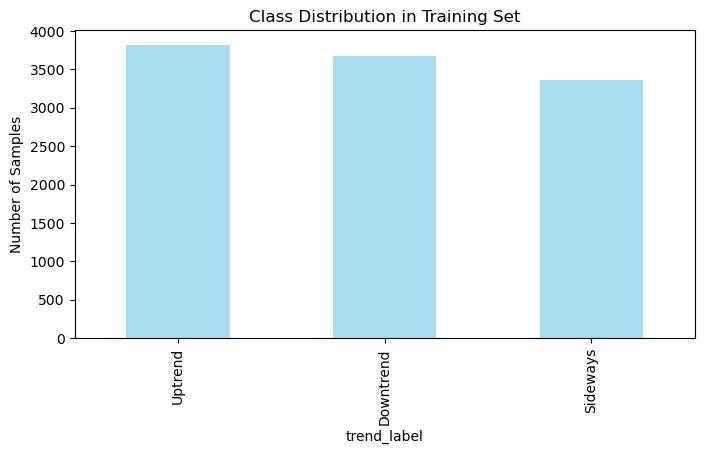

In [35]:
# Verification of class distribution in targey variable for training features
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
train_df['trend_label'].value_counts().plot(kind='bar', color='skyblue', alpha=0.7)
plt.title("Class Distribution in Training Set")
plt.ylabel("Number of Samples")
plt.savefig("../visuals/eda/Class Distribution in Training Set.png", dpi=300, bbox_inches="tight")
plt.show()

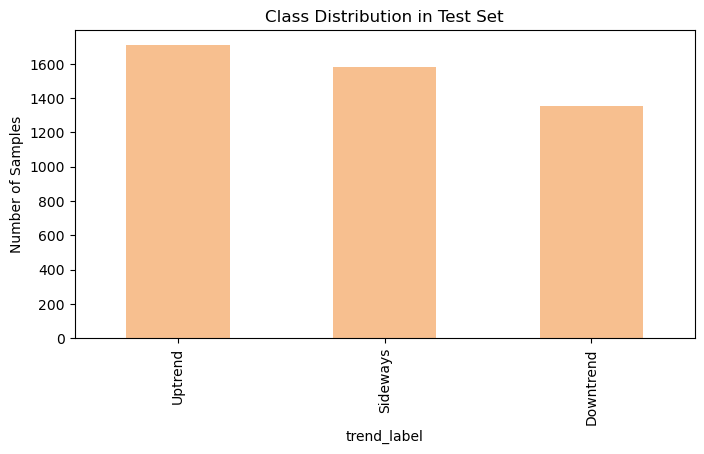

In [36]:
# Verification of class distribution in target variable for test
plt.figure(figsize=(8,4))
test_df['trend_label'].value_counts().plot(kind='bar', color='sandybrown', alpha=0.7)
plt.title("Class Distribution in Test Set")
plt.ylabel("Number of Samples")
plt.savefig("../visuals/eda/Class Distribution in Test Set.png", dpi=300, bbox_inches="tight")
plt.show()

### Timeline Plot for Train vs Test Split

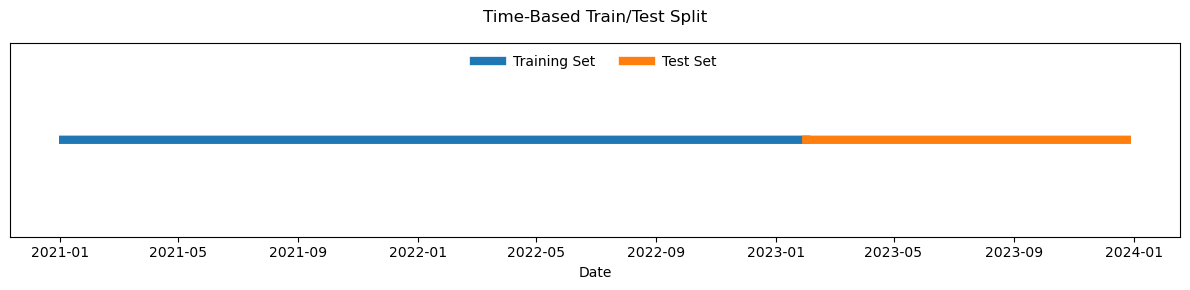

In [37]:
# Create figure
plt.figure(figsize=(12, 3))

# Plot training period
plt.plot(
    train_df["date"],
    [1] * len(train_df),
    label="Training Set",
    linewidth=6
)

# Plot testing period
plt.plot(
    test_df["date"],
    [1] * len(test_df),
    label="Test Set",
    linewidth=6
)

# Formatting
plt.yticks([])
plt.xlabel("Date")
plt.title("Time-Based Train/Test Split", pad=15)
plt.legend(loc="upper center", ncol=2, frameon=False)

plt.tight_layout()

# Save as PNG
plt.savefig(
    "../visuals/model_performance/time_based_train_test_split.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Build Logistic Regression Model

In [38]:
# Filling missing values with train median
X_train = X_train.fillna(X_train.median())
X_test  = X_test.fillna(X_train.median())

In [39]:
# Create the model
log_reg = LogisticRegression(max_iter=1000)

# Fit the model on training data
log_reg.fit(X_train, y_train)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("log_reg", LogisticRegression(max_iter=1000))
])

pipeline.fit(X_train, y_train)

c:\Users\ephra\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('scaler', StandardScaler()),
                ('log_reg', LogisticRegression(max_iter=1000))])

In [40]:
y_pred = log_reg.predict(X_test)

In [41]:
# Save the pipeline
joblib.dump(pipeline, "../models/logreg_pipeline.pkl")

['../models/logreg_pipeline.pkl']

#### Model evaluation


In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.3414319501182541

Classification Report:
               precision    recall  f1-score   support

   Downtrend       0.29      0.18      0.22      1356
    Sideways       0.34      0.28      0.31      1583
     Uptrend       0.36      0.53      0.43      1712

    accuracy                           0.34      4651
   macro avg       0.33      0.33      0.32      4651
weighted avg       0.33      0.34      0.33      4651


Confusion Matrix:
 [[246 376 734]
 [272 441 870]
 [333 478 901]]


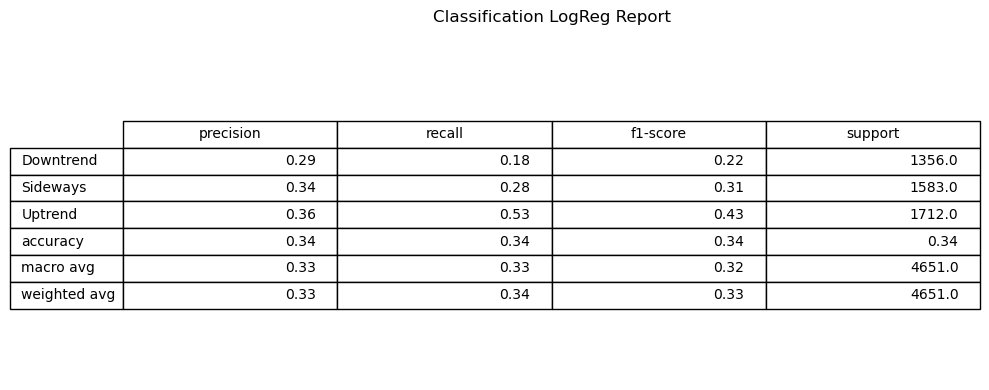

In [43]:
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report)

report_df

# Transpose for better readability
report_df_t = report_df.T.round(2)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('off')

table = ax.table(
    cellText=report_df_t.values,
    colLabels=report_df_t.columns,
    rowLabels=report_df_t.index,
    loc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.5)

plt.title("Classification LogReg Report", pad=20)
plt.tight_layout()

plt.savefig("../visuals/summary/classification_logreg_report.png", dpi=300, bbox_inches='tight')
plt.show()

### Visualization of model results

#### Confusion Matrix Logistic Regression

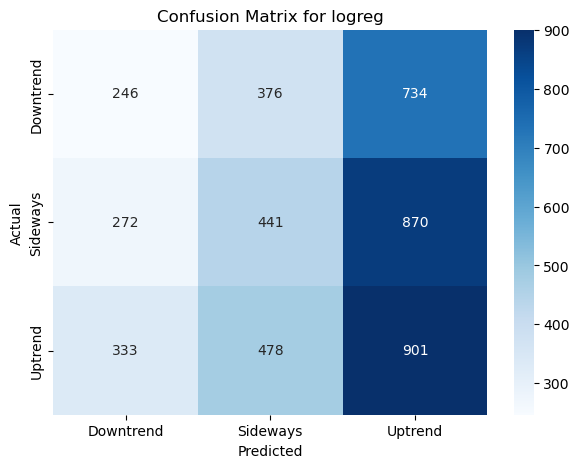

In [44]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=log_reg.classes_, 
            yticklabels=log_reg.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for logreg')
plt.savefig("../visuals/model_performance/Confusion Matrix for logreg.png", dpi=300, bbox_inches="tight")
plt.show()

#### Classification Report

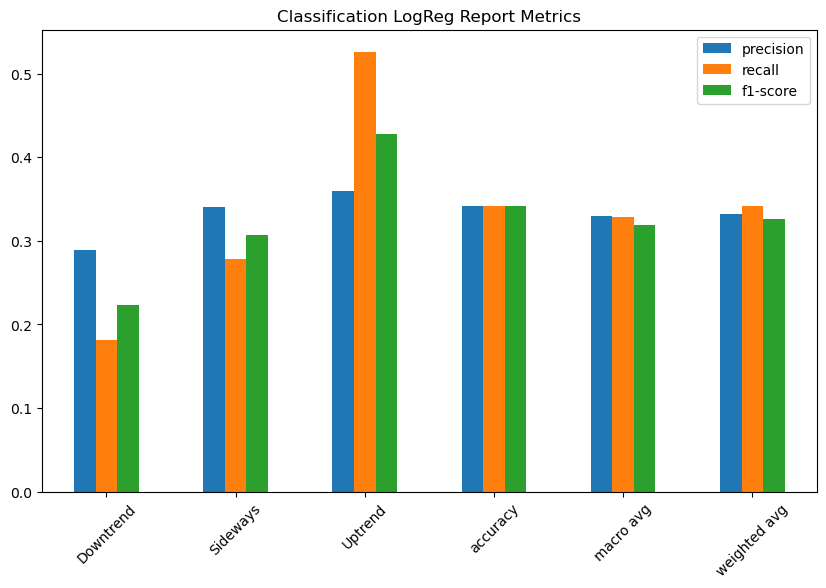

In [45]:
report = classification_report(y_test, y_pred, output_dict=True)
df_report = pd.DataFrame(report).transpose()

df_report[['precision','recall','f1-score']].plot(kind='bar', figsize=(10,6))
plt.title('Classification LogReg Report Metrics')
plt.xticks(rotation=45)
plt.savefig("../visuals/eda/Classification Report Metrics.png", dpi=300, bbox_inches="tight")
plt.show()

#### Accuracy: 
The overall model accuracy is 34.17% which means the model is barely better than random chance. It is biased to towards the uptrend as results indicate; Downtrend: 16% recall as model misses 84% of downtrends, Sideways: 22% recall as model misses 78% of sideways and Uptrend: 60% recall as model correctly identifies more than half of uptrends.

#### Confusion Matrix Interpretation: 
Most of the time, the model predicts “Uptrend”. 
True Downtrend → 778 incorrectly predicted as Uptrend
True Sideways → 874 incorrectly predicted as Uptrend
True Uptrend → 920 correctly predicted as Uptrend

#### Precision: 
When the model predicts a class, how often is it correct is the goal. The precision result is low accross the trend labels which imply very weak confidence with Downtrend precision = 27%, Sideways precision = 35% and Uptrend precision = 36%.

#### Macro F1-Score: 
This is at 0.31 which means none of the classes has been modelled well. 

Overall, there is need for improvement.